In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from typing import Annotated, TypedDict, Optional
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0)

llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000023E1404EE40>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023E1404F8C0>, model_name='llama-3.1-8b-instant', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### 1 - Build the graph

In [5]:
class ChatState(TypedDict):
    messages : Annotated[list, add_messages]

In [6]:
def chatbot(state=ChatState) : 
    answer = llm.invoke(state["messages"])
    return {"messages": [answer]}

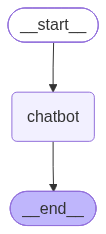

In [7]:
graph = StateGraph(ChatState)

graph.add_node("chatbot",chatbot)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot",END)

builder = graph.compile()
builder

In [8]:
res = builder.invoke(
    {
        "messages" : [HumanMessage("Hi")]
    }
)

res['messages']

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='57491146-ed35-4dad-ba9d-3106b52806da'),
 AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.028630965, 'completion_tokens_details': None, 'prompt_time': 0.002297943, 'prompt_tokens_details': None, 'queue_time': 0.050377877, 'total_time': 0.030928908}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9d4b-a8e4-7dc3-a702-b1888f8fab31-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]

### 2 - Give it a memory

In [9]:
checkpointer = MemorySaver()

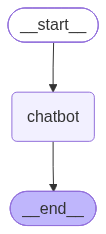

In [10]:
graph = StateGraph(ChatState)

graph.add_node("chatbot",chatbot)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot",END)

builder = graph.compile(checkpointer=checkpointer)
builder

In [11]:
thread_1 = {"configurable": {"thread_id": "1"}}

In [12]:
result1 = builder.invoke({"messages" : [HumanMessage("Hi my name is Rohan.")]}, thread_1)
result1

{'messages': [HumanMessage(content='Hi my name is Rohan.', additional_kwargs={}, response_metadata={}, id='2e3eca83-a5dc-4874-83ed-b5d58ee7b317'),
  AIMessage(content="Hello Rohan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 42, 'total_tokens': 69, 'completion_time': 0.05114491, 'completion_tokens_details': None, 'prompt_time': 0.001960338, 'prompt_tokens_details': None, 'queue_time': 0.052755051, 'total_time': 0.053105248}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9d4b-aa08-7723-ae04-1b7283c18cb0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 27, 'total_tokens': 69})]}

In [13]:
result2 = builder.invoke({"messages" : [HumanMessage("What is my name?.")]}, thread_1)
print(result2)

{'messages': [HumanMessage(content='Hi my name is Rohan.', additional_kwargs={}, response_metadata={}, id='2e3eca83-a5dc-4874-83ed-b5d58ee7b317'), AIMessage(content="Hello Rohan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 42, 'total_tokens': 69, 'completion_time': 0.05114491, 'completion_tokens_details': None, 'prompt_time': 0.001960338, 'prompt_tokens_details': None, 'queue_time': 0.052755051, 'total_time': 0.053105248}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9d4b-aa08-7723-ae04-1b7283c18cb0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 27, 'total_tokens': 69}), HumanMessage(content='What is my name?.', additional_kwargs={}, response_metadata

### 3- Prove Isolation

In [14]:
thread_1 = {"configurable": {"thread_id": "2"}}
result2 = builder.invoke({"messages" : [HumanMessage("What is my name?.")]}, thread_1)
print(result2)

{'messages': [HumanMessage(content='What is my name?.', additional_kwargs={}, response_metadata={}, id='cd4c92dc-a9c9-452c-9362-05e8292f3d9d'), AIMessage(content="I don't have any information about your name. I'm a large language model, I don't have the ability to retain information about individual users or their personal details. Each time you interact with me, it's a new conversation and I don't have any prior knowledge about you. If you'd like to share your name with me, I'd be happy to chat with you!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 40, 'total_tokens': 118, 'completion_time': 0.08720723, 'completion_tokens_details': None, 'prompt_time': 0.002790307, 'prompt_tokens_details': None, 'queue_time': 0.064328272, 'total_time': 0.089997537}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_

#### Why it is an security concern?

A fixed or predictable thread_id in production is a security concern because it can allow unauthorized users to access or interfere with another user's conversation if thread IDs are guessable or reused. It can also lead to session mix-ups, data leakage, and conversation hijacking.

### 4 - Inspect the Memory

In [17]:
s = builder.get_state(thread_1)
s

StateSnapshot(values={'messages': [HumanMessage(content='What is my name?.', additional_kwargs={}, response_metadata={}, id='cd4c92dc-a9c9-452c-9362-05e8292f3d9d'), AIMessage(content="I don't have any information about your name. I'm a large language model, I don't have the ability to retain information about individual users or their personal details. Each time you interact with me, it's a new conversation and I don't have any prior knowledge about you. If you'd like to share your name with me, I'd be happy to chat with you!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 40, 'total_tokens': 118, 'completion_time': 0.08720723, 'completion_tokens_details': None, 'prompt_time': 0.002790307, 'prompt_tokens_details': None, 'queue_time': 0.064328272, 'total_time': 0.089997537}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provid

In [18]:
for i, msg in enumerate(s.values["messages"], start=1):
    print(f"{i}. Type: {msg.type}")
    print(f"   Content: {msg.content}")
    print("-" * 40)


1. Type: human
   Content: What is my name?.
----------------------------------------
2. Type: ai
   Content: I don't have any information about your name. I'm a large language model, I don't have the ability to retain information about individual users or their personal details. Each time you interact with me, it's a new conversation and I don't have any prior knowledge about you. If you'd like to share your name with me, I'd be happy to chat with you!
----------------------------------------


In [19]:
## update state 

builder.update_state(
    thread_1,
    {
        "messages": [
            HumanMessage(content="This is a new message added using update_state.")
        ]
    }
)

# Verify the updated state
updated_state = builder.get_state(thread_1)
updated_state

StateSnapshot(values={'messages': [HumanMessage(content='What is my name?.', additional_kwargs={}, response_metadata={}, id='cd4c92dc-a9c9-452c-9362-05e8292f3d9d'), AIMessage(content="I don't have any information about your name. I'm a large language model, I don't have the ability to retain information about individual users or their personal details. Each time you interact with me, it's a new conversation and I don't have any prior knowledge about you. If you'd like to share your name with me, I'd be happy to chat with you!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 40, 'total_tokens': 118, 'completion_time': 0.08720723, 'completion_tokens_details': None, 'prompt_time': 0.002790307, 'prompt_tokens_details': None, 'queue_time': 0.064328272, 'total_time': 0.089997537}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provid

In [20]:
print("\n=== Messages After update_state ===")
for i, msg in enumerate(updated_state.values["messages"], start=1):
    print(f"{i}. Type: {msg.type}")
    print(f"   Content: {msg.content}")
    print("-" * 40)


=== Messages After update_state ===
1. Type: human
   Content: What is my name?.
----------------------------------------
2. Type: ai
   Content: I don't have any information about your name. I'm a large language model, I don't have the ability to retain information about individual users or their personal details. Each time you interact with me, it's a new conversation and I don't have any prior knowledge about you. If you'd like to share your name with me, I'd be happy to chat with you!
----------------------------------------
3. Type: human
   Content: This is a new message added using update_state.
----------------------------------------


### 5- Trim a Long HIstory 

In [21]:
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage,
    trim_messages,
)

In [22]:
messages = [
    SystemMessage(content="You are a helpful AI assistant."),
    HumanMessage(content="Hi! My name is Alice."),
    AIMessage(content="Hello Alice! Nice to meet you."),
    HumanMessage(content="I work as a software engineer."),
    AIMessage(content="That's great! What technologies do you use?"),
    HumanMessage(content="Mostly Python, LangChain, and FastAPI."),
    AIMessage(content="Those are excellent tools for building AI applications."),
    HumanMessage(content="Can you recommend some best practices?"),
    AIMessage(content="Sure! Focus on modular design, testing, logging, and observability."),
    HumanMessage(content="Also remind me that my favorite language is Python."),
]


In [24]:
# Create the trimmer
trimmer = trim_messages(
    max_tokens=65,              # Small token budget
    strategy="last",            # Keep the latest messages
    token_counter=llm,
    include_system=True,        # Always preserve the system message
    start_on="human",           # Trim so history starts with a HumanMessage
)

In [25]:
trimmed_messages = trimmer.invoke(messages)
trimmed_messages

[SystemMessage(content='You are a helpful AI assistant.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Can you recommend some best practices?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Sure! Focus on modular design, testing, logging, and observability.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Also remind me that my favorite language is Python.', additional_kwargs={}, response_metadata={})]

In [26]:
print("Original messages:", len(messages))
print("Trimmed messages:", len(trimmed_messages))
print()

Original messages: 10
Trimmed messages: 4



In [27]:
print("=== Messages After Trimming ===")
for i, msg in enumerate(trimmed_messages, start=1):
    print(f"{i}. {msg.type.upper()}")
    print(msg.content)
    print("-" * 50)

=== Messages After Trimming ===
1. SYSTEM
You are a helpful AI assistant.
--------------------------------------------------
2. HUMAN
Can you recommend some best practices?
--------------------------------------------------
3. AI
Sure! Focus on modular design, testing, logging, and observability.
--------------------------------------------------
4. HUMAN
Also remind me that my favorite language is Python.
--------------------------------------------------


### LangSmith Observability

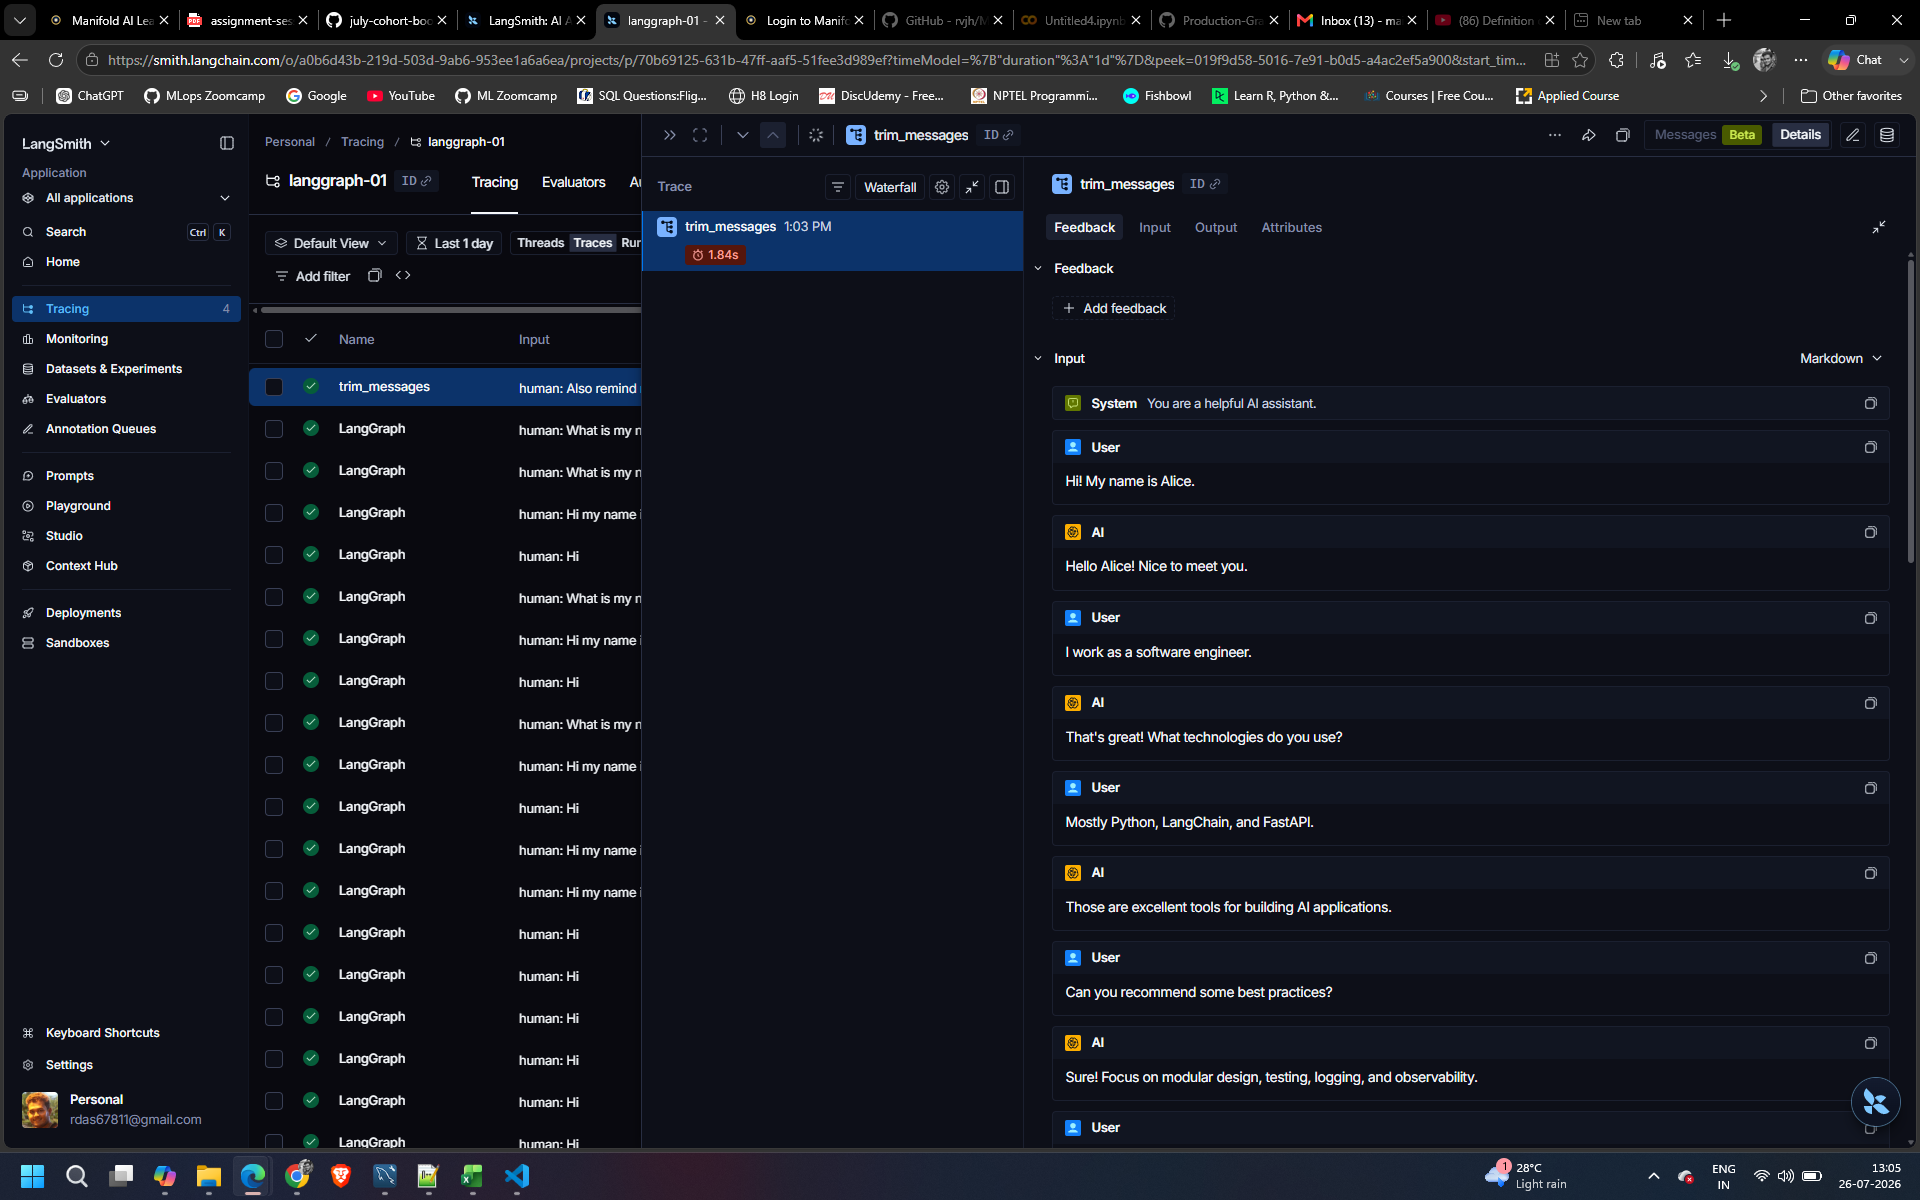

#### 1. What exactly does the add_messages reducer do, and what would break without it?

The add_messages reducer appends new messages to the existing conversation history instead of replacing it. Without it, each new invoke() could overwrite the previous messages, causing the agent to lose conversation context.

#### 2. What does attaching a checkpointer change about how invoke behaves?

A checkpointer persists the graph's state (such as messages) across invocations for a given thread_id. This allows each invoke() to continue from the previous conversation instead of starting with an empty state.

#### 3. Give one reason you'd trim history beyond just fitting the context window.

Trimming history can improve performance and reduce latency by sending fewer tokens to the model. It also helps remove older or less relevant messages, keeping the model focused on the current task.